In [117]:
## checking the dataset properties

import pandas as pd

df= pd.read_csv("../Dataset/sample_tickets_dataset.csv")
print(df.shape)
print(df.columns.tolist)
print(df.dtypes)

(3000, 17)
<bound method IndexOpsMixin.tolist of Index(['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age',
       'Customer Gender', 'Product Purchased', 'Date of Purchase',
       'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status',
       'Resolution', 'Ticket Priority', 'Ticket Channel',
       'First Response Time', 'Time to Resolution',
       'Customer Satisfaction Rating'],
      dtype='str')>
Ticket ID                         int64
Customer Name                       str
Customer Email                      str
Customer Age                      int64
Customer Gender                     str
Product Purchased                   str
Date of Purchase                    str
Ticket Type                         str
Ticket Subject                      str
Ticket Description                  str
Ticket Status                       str
Resolution                          str
Ticket Priority                     str
Ticket Channel                      str
Firs

In [118]:
for columns in df.columns:
    print(df[columns].value_counts())

Ticket ID
1       1
2       1
3       1
4       1
5       1
       ..
2996    1
2997    1
2998    1
2999    1
3000    1
Name: count, Length: 3000, dtype: int64
Customer Name
Gary Torres           4
Jessica Peterson      3
Samantha Foster       3
Sarah Garcia          3
Scott Brooks          3
                     ..
Margaret Rodriguez    1
Lucas Anderson        1
Alexis Ramos          1
Aiden McDonald        1
Stephanie Foster      1
Name: count, Length: 2722, dtype: int64
Customer Email
cdavis@gmail.com                 2
lbaker@protonmail.com            2
katherinedavis@company.com       2
abailey@work.org                 2
ecruz@live.com                   2
                                ..
margaretrodriguez@hotmail.com    1
lucasanderson@protonmail.com     1
ramos55@corp.io                  1
aiden.mcdonald@protonmail.com    1
sfoster@outlook.com              1
Name: count, Length: 2994, dtype: int64
Customer Age
23    73
30    69
44    66
48    65
46    64
42    63
63    63
29    

## what we have learnt from the initial raw dataset

1. ticket type will be the main classification target, based on what type of theticket is talking about, we will predict the priority of the ticket

2. the ticket description has one main issue of having {product purchased} and {error_message} which are unfilled parameters which makes this column very weak by itelse. So we combine it with ticket subject to me used more reliablely

3. we can remove unneccessary columns like ticket id, customer name, customer emal, age, gender etc

In [119]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [120]:
df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Amanda Hayes,amanda_hayes@hotmail.com,67,Female,ReportEdge,09-06-2022,Product Inquiry,What is the difference between standard and pr...,My manager asked me to evaluate this tool and ...,Closed,Feature availability confirmed across all supp...,High,Phone,3.72 hours,10.9 hours,4.0
1,2,Catherine Howard,howard63@live.com,56,Male,ShipTrack,17-08-2025,Billing Inquiry,Annual subscription renewed without any warnin...,Can someone please look into a billing discrep...,Closed,Payment method updated by support agent. Servi...,High,Phone,6.0 hours,20.2 hours,4.0
2,3,Samuel Morales,samuel291@work.org,47,Male,FlexPlan Premium,04-01-2024,Product Inquiry,How many users can I add under the business plan,We're a growing company and I want to see if y...,Closed,Full feature comparison emailed. Customer opte...,Low,Chat,64.95 hours,7.9 days,3.0
3,4,Tyler Ramos,tramos@protonmail.com,57,Female,BrightPOS,22-12-2024,Technical Issue,Mobile app crashes immediately on launch,Writing in because I've spent Tuesday afternoo...,Resolved,Server-side configuration corrected. User conf...,Critical,Email,1.67 hours,20.0 hours,3.0
4,5,Elijah Turner,turner34@live.com,66,Female,MailForge,18-12-2023,Billing Inquiry,Charged twice for my subscription this month,I'm writing to flag a billing issue I noticed ...,Resolved,Proration calculated and applied. Updated invo...,Medium,Phone,20.04 hours,6.8 days,4.0


In [121]:
print(df.shape)

(3000, 17)


In [122]:
## checking null values
df.isnull().sum()

Ticket ID                          0
Customer Name                      0
Customer Email                     0
Customer Age                       0
Customer Gender                    0
Product Purchased                  0
Date of Purchase                   0
Ticket Type                        0
Ticket Subject                     0
Ticket Description                 0
Ticket Status                      0
Resolution                      1158
Ticket Priority                    0
Ticket Channel                     0
First Response Time                0
Time to Resolution              1158
Customer Satisfaction Rating    1158
dtype: int64

In [123]:
## dropping unneccessary columns
print(df.columns.tolist())

['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age', 'Customer Gender', 'Product Purchased', 'Date of Purchase', 'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status', 'Resolution', 'Ticket Priority', 'Ticket Channel', 'First Response Time', 'Time to Resolution', 'Customer Satisfaction Rating']


In [124]:
df = df.drop(columns=['Ticket ID','Customer Name', 'Customer Email', 'Customer Age', 'Customer Gender',
               'Date of Purchase','First Response Time','Time to Resolution','Resolution', 
               "Customer Satisfaction Rating"],errors='ignore')

In [125]:
df.head()

,Product Purchased,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Ticket Priority,Ticket Channel
0,ReportEdge,Product Inquiry,What is the difference between standard and pr...,My manager asked me to evaluate this tool and ...,Closed,High,Phone
1,ShipTrack,Billing Inquiry,Annual subscription renewed without any warnin...,Can someone please look into a billing discrep...,Closed,High,Phone
2,FlexPlan Premium,Product Inquiry,How many users can I add under the business plan,We're a growing company and I want to see if y...,Closed,Low,Chat
3,BrightPOS,Technical Issue,Mobile app crashes immediately on launch,Writing in because I've spent Tuesday afternoo...,Resolved,Critical,Email
4,MailForge,Billing Inquiry,Charged twice for my subscription this month,I'm writing to flag a billing issue I noticed ...,Resolved,Medium,Phone


In [126]:
## checking null values again
df.isnull().sum()

Product Purchased     0
Ticket Type           0
Ticket Subject        0
Ticket Description    0
Ticket Status         0
Ticket Priority       0
Ticket Channel        0
dtype: int64

for ticket types count: 

Ticket Type
Technical Issue    1020
Billing Inquiry     660
Account Access      570
Refund Request      450
Product Inquiry     300
Name: count, dtype: int64

for ticket priority count: 

Ticket Priority
High        1183
Medium       902
Critical     576
Low          339
Name: count, dtype: int64


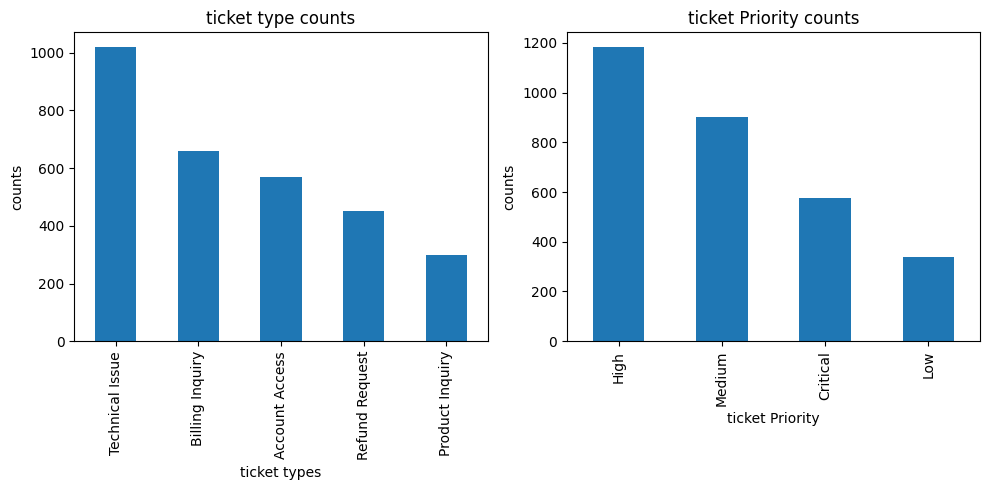

In [127]:
print("for ticket types count: \n")
print(df['Ticket Type'].value_counts())

print("\nfor ticket priority count: \n")
print(df['Ticket Priority'].value_counts())
ticket_type_counts = df['Ticket Type'].value_counts()
ticket_priority_counts = df['Ticket Priority'].value_counts()

figure, axes = plt.subplots(1,2, figsize=(10,5))

ticket_type_counts.plot(kind='bar',ax=axes[0])
axes[0].set_xlabel("ticket types")
axes[0].set_title("ticket type counts")
axes[0].set_ylabel("counts")

ticket_priority_counts.plot(kind='bar',ax=axes[1])
axes[1].set_xlabel("ticket Priority")
axes[1].set_title("ticket Priority counts")
axes[1].set_ylabel("counts")



plt.tight_layout()
plt.show()

### insight from the graphs
- technical issue has the highest ticket count while product enquirey has the least
- high ticket priotiry is the most common where as low ticket priority is the least

In [128]:
## checking the correlation between priority and type using heatmap
print(pd.crosstab(df['Ticket Type'], df['Ticket Priority']))
# this crosstab shows that for each type of ticket how many tickets are criticla, high, low and medium

Ticket Priority  Critical  High  Low  Medium
Ticket Type                                 
Account Access        131   262   22     155
Billing Inquiry        80   272   85     223
Product Inquiry        21    50  107     122
Refund Request         43   127   68     212
Technical Issue       301   472   57     190


<Axes: xlabel='Ticket Priority', ylabel='Ticket Type'>

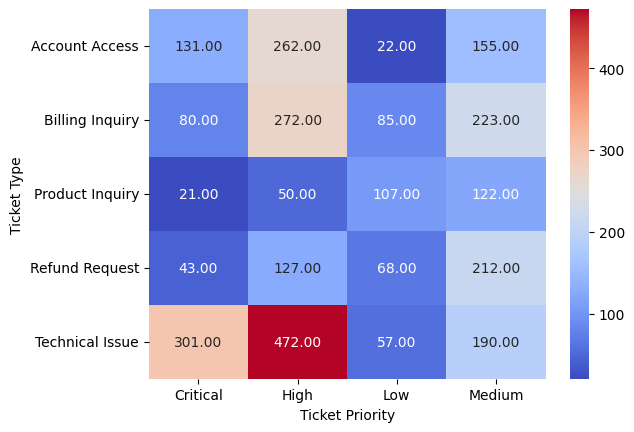

In [129]:
sns.heatmap(pd.crosstab(df['Ticket Type'], df['Ticket Priority']), annot=True,fmt=".2f", cmap="coolwarm")

### insight from heatmap
- Technical Issues are predominantly High priority/. 
- Product Inquiry leans Medium/Low

this makes ticket priority as a useful feature in classificatin

Ticket Channel
Email           1088
Chat             812
Phone            758
Social Media     342
Name: count, dtype: int64


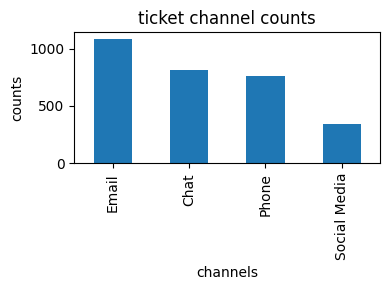

In [130]:
## observing ticket channel distribution
# here we will check choch channel gets most tickets

print(df["Ticket Channel"].value_counts())
ticket_channel_counts = df["Ticket Channel"].value_counts()

plt.figure(figsize=(4,3))

ticket_channel_counts.plot(kind="bar")
plt.title("ticket channel counts")
plt.xlabel("channels")
plt.ylabel("counts")
plt.tight_layout()

plt.show()

### insight from the channel counts
- emails are the major source of connecting
- social media is the least used

In [131]:
## obsering text length distribution
df['description_length'] = df['Ticket Description'].str.len()
df.head()

,Product Purchased,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Ticket Priority,Ticket Channel,description_length
0,ReportEdge,Product Inquiry,What is the difference between standard and pr...,My manager asked me to evaluate this tool and ...,Closed,High,Phone,205
1,ShipTrack,Billing Inquiry,Annual subscription renewed without any warnin...,Can someone please look into a billing discrep...,Closed,High,Phone,201
2,FlexPlan Premium,Product Inquiry,How many users can I add under the business plan,We're a growing company and I want to see if y...,Closed,Low,Chat,251
3,BrightPOS,Technical Issue,Mobile app crashes immediately on launch,Writing in because I've spent Tuesday afternoo...,Resolved,Critical,Email,308
4,MailForge,Billing Inquiry,Charged twice for my subscription this month,I'm writing to flag a billing issue I noticed ...,Resolved,Medium,Phone,185


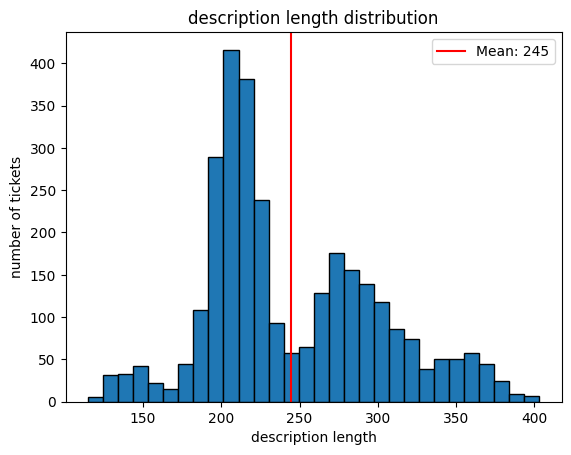

In [132]:
# plotting the histogram
plt.hist(df['description_length'], bins=30, edgecolor='black')
plt.xlabel('description length')
plt.ylabel('number of tickets')
plt.title("description length distribution")
plt.axvline(df['description_length'].mean(), color='red', label=f"Mean: {df['description_length'].mean():.0f}")
##axvline = draws a vertical line at mean
plt.legend()
plt.show()

### insights from description length distribution
- most of the tickets have characters from about 190 to 210 with the maximumn tickets being at 195 characters length
- there might be some description that might be too brief for the model to classify well